# Exploratory Data Analysis (EDA) Project
### Task 3 — What drives diamond prices?

**Objective:** Analyze a dataset to uncover patterns and trends.

**Dataset:** The classic *diamonds* dataset — ~53,940 diamonds with their carat weight, cut, color, clarity,
dimensions and price. It is a good EDA dataset because it mixes numeric and ordinal-categorical features against
a single continuous target (`price`), giving plenty of scope for statistical summaries, correlation analysis and
storytelling visuals.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)
pd.set_option("display.max_columns", None)


## 1. Load & inspect the data

In [2]:
df = pd.read_csv("diamonds.csv")
print(df.shape)
df.head()


(53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [4]:
df.isna().sum()


carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

## 2. Data cleaning
A quick sanity check: a diamond can't have zero physical dimensions, so rows with `x`, `y` or `z` equal to 0 are
data-entry errors and are dropped.


In [5]:
before = len(df)
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)].copy()
print(f"Dropped {before - len(df)} rows with invalid dimensions. Remaining: {len(df)}")


Dropped 20 rows with invalid dimensions. Remaining: 53920


## 3. Statistical summary

In [6]:
df.describe()


,carat,depth,table,price,x,y,z
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [7]:
df.describe(include="object")


/tmp/ipykernel_179/3764884355.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,cut,color,clarity
count,53920,53920,53920
unique,5,7,8
top,Ideal,G,SI1
freq,21548,11284,13063


## 4. Distribution of the target variable — price

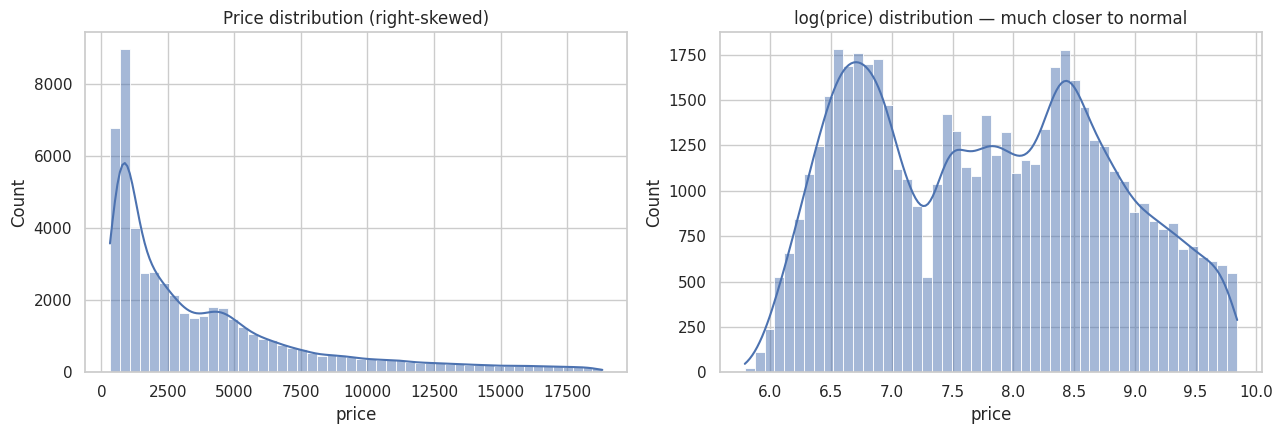

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Price distribution (right-skewed)")

sns.histplot(np.log1p(df["price"]), bins=50, kde=True, ax=axes[1])
axes[1].set_title("log(price) distribution — much closer to normal")
plt.tight_layout()
plt.show()


## 5. Categorical influencing factors — cut, color, clarity
These are the three "4 Cs" quality grades captured in the data (alongside carat).


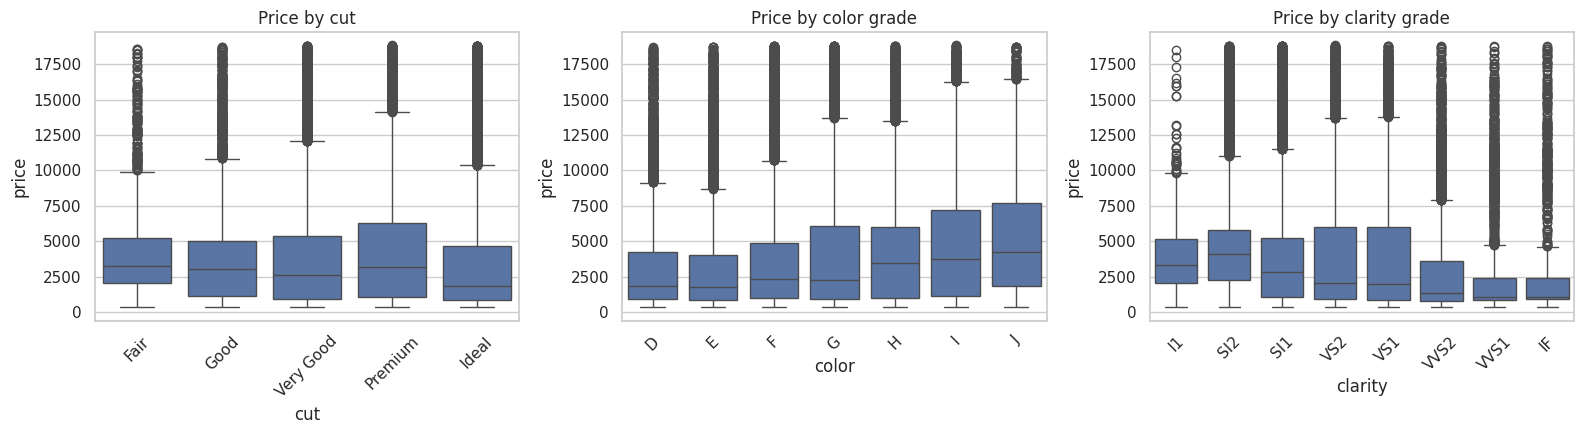

In [9]:
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = sorted(df["color"].unique())
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=df, x="cut", y="price", order=cut_order, ax=axes[0])
axes[0].set_title("Price by cut")

sns.boxplot(data=df, x="color", y="price", order=color_order, ax=axes[1])
axes[1].set_title("Price by color grade")

sns.boxplot(data=df, x="clarity", y="price", order=clarity_order, ax=axes[2])
axes[2].set_title("Price by clarity grade")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


**Observation:** median price barely changes — or even dips slightly — as cut/color/clarity quality
improves. This is counter-intuitive until you account for `carat`: buyers of small diamonds are more willing to
pay for a higher grade, while big, expensive diamonds are sold across all grades. This is explored below.


## 6. Carat — the dominant driver of price

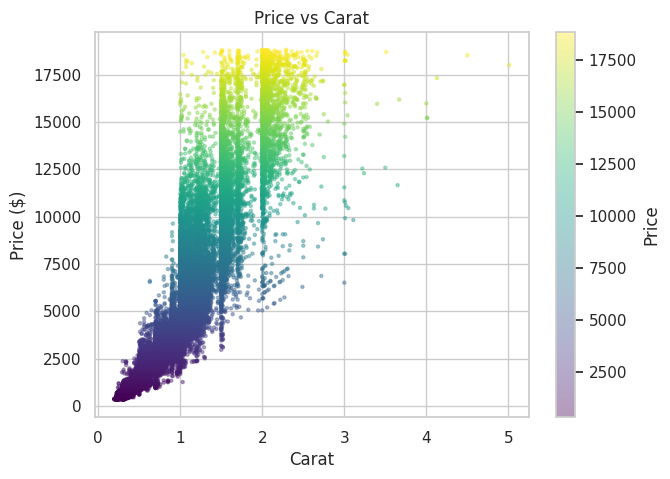

Correlation between carat and price: 0.922


In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(df["carat"], df["price"], c=df["price"], cmap="viridis", s=5, alpha=0.4)
ax.set_xlabel("Carat")
ax.set_ylabel("Price ($)")
ax.set_title("Price vs Carat")
plt.colorbar(scatter, label="Price")
plt.show()

print("Correlation between carat and price:", round(df["carat"].corr(df["price"]), 3))


## 7. Correlation heatmap (numeric features)

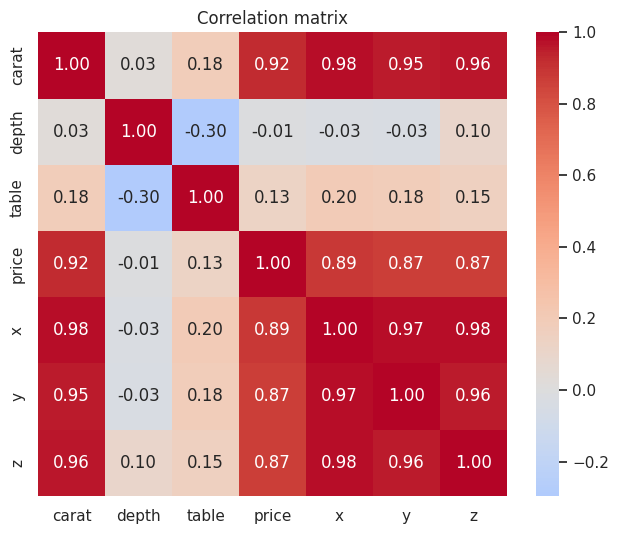

In [11]:
numeric_cols = ["carat", "depth", "table", "price", "x", "y", "z"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


**Key influencing factors ranked by correlation with price:**


In [12]:
corr["price"].drop("price").sort_values(ascending=False)


carat    0.921592
x        0.887231
z        0.868206
y        0.867864
table    0.127245
depth   -0.010729
Name: price, dtype: float64

## 8. Carat, controlling for clarity
To untangle the counter-intuitive boxplots in Section 5, price vs carat is plotted separately for each clarity
grade.


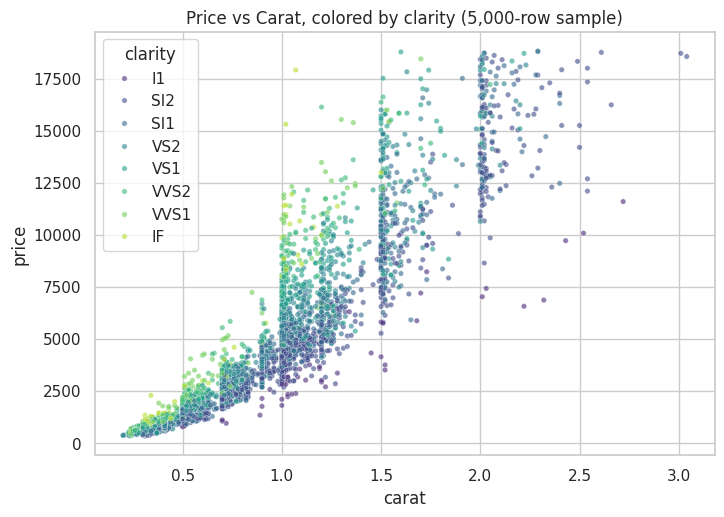

In [13]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=df.sample(5000, random_state=42), x="carat", y="price", hue="clarity",
                 hue_order=clarity_order, palette="viridis", s=15, alpha=0.6)
plt.title("Price vs Carat, colored by clarity (5,000-row sample)")
plt.show()


**Observation:** within any given carat size, higher-clarity stones do command a visible price premium —
the quality grades matter, but their effect is dwarfed by carat weight, which explains the flat boxplots in
Section 5.


## 9. Summary report

In [14]:
avg_price_by_cut = df.groupby("cut")["price"].mean().reindex(cut_order).round(0)
avg_price_by_clarity = df.groupby("clarity")["price"].mean().reindex(clarity_order).round(0)
avg_carat_by_cut = df.groupby("cut")["carat"].mean().reindex(cut_order).round(2)

print("Average price by cut:\n", avg_price_by_cut, "\n")
print("Average carat by cut:\n", avg_carat_by_cut, "\n")
print("Average price by clarity:\n", avg_price_by_clarity)


Average price by cut:
 cut
Fair         4358.0
Good         3926.0
Very Good    3982.0
Premium      4580.0
Ideal        3457.0
Name: price, dtype: float64 

Average carat by cut:
 cut
Fair         1.05
Good         0.85
Very Good    0.81
Premium      0.89
Ideal        0.70
Name: carat, dtype: float64 

Average price by clarity:
 clarity
I1      3926.0
SI2     5060.0
SI1     3994.0
VS2     3923.0
VS1     3839.0
VVS2    3284.0
VVS1    2520.0
IF      2865.0
Name: price, dtype: float64


### Key findings
1. **Carat is by far the strongest driver of price** (correlation ≈ 0.92), and its relationship with price is
   non-linear — price accelerates as carat increases.
2. **Cut, color and clarity have a real but secondary effect.** Their influence only becomes visible once carat
   is held constant (Section 8); on their own, average price across cut/clarity groups looks flat or even
   inverted because premium-grade stones skew toward smaller carat weights (Section 9 table).
3. **Diamond dimensions (`x`, `y`, `z`) are highly collinear with carat** (correlation > 0.95), as expected
   since they all describe physical size — in a predictive model, only one of these would typically be kept to
   avoid redundancy.
4. **Price is right-skewed**; a log transform makes it far closer to normally distributed, which would matter
   if this dataset were used for linear-model-based prediction.

### Recommendation
For a buyer optimizing value, the data suggests the biggest price lever is carat weight — a slightly larger
stone costs disproportionately more than upgrading cut/color/clarity by a grade. For a seller or pricing model,
carat should be the primary feature, with clarity/color/cut as secondary adjustments and duplicate dimension
columns removed to avoid multicollinearity.

**Expected outcome achieved:** practiced statistical summarization, multi-variable visualization, and
correlation-based reasoning to explain *why* a variable behaves the way it does — not just *that* it correlates.
